# Body display

Visualization only: render the SenecaBot model, run a physics sanity drop, and replay a reference trajectory. Model loading is reused from `simulation.core.data_loader.load_model`; processing lives in `simulation.mocap`.

In [1]:
import numpy as np
import mujoco
import mediapy as media
import matplotlib.pyplot as plt

from simulation.config import pipeline as P
from simulation.config.parameters import parameters
from simulation.core.data_loader import load_model
from simulation.mocap import io, kinematics, build

def show(model, data, camera="follow", w=1280, h=720):
    r = mujoco.Renderer(model, width=w, height=h)
    mujoco.mj_forward(model, data)
    r.update_scene(data, camera=camera)
    media.show_image(r.render()); r.close()

## 1. Load model

In [2]:
model, data = load_model(P.XML_PATH, parameters)
model.nq, model.nv

(19, 18)

## 2. Standing pose

""

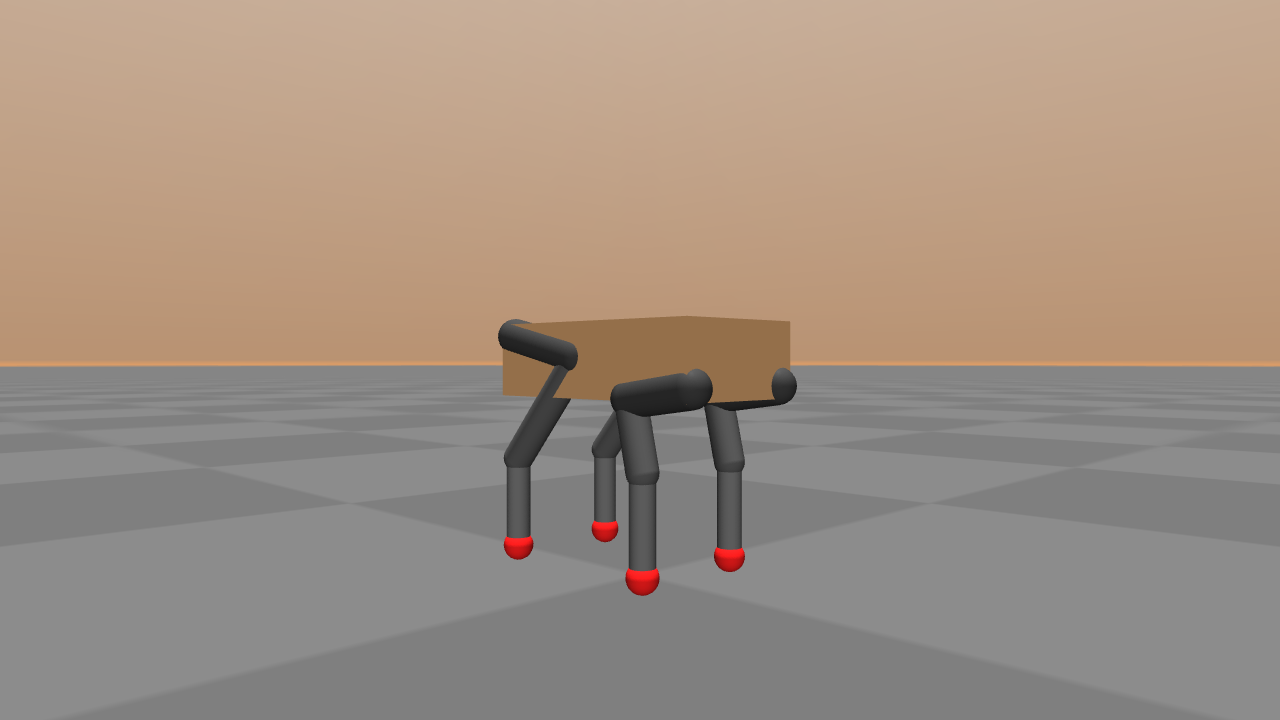

In [3]:
mujoco.mj_resetData(model, data)
front = np.radians([82, 95, 13])
rear  = np.radians([-78, -120, -42])
for leg, vals in [("fl", front), ("fr", front), ("bl", rear), ("br", rear)]:
    for joint, v in zip(P.JOINT_ORDER, vals):
        data.joint(f"{leg}_{joint}_joint").qpos = v
data.qpos[0:3] = [0, 0, 0.35]
show(model, data)

## 3. Physics drop test

This browser does not support the video tag.


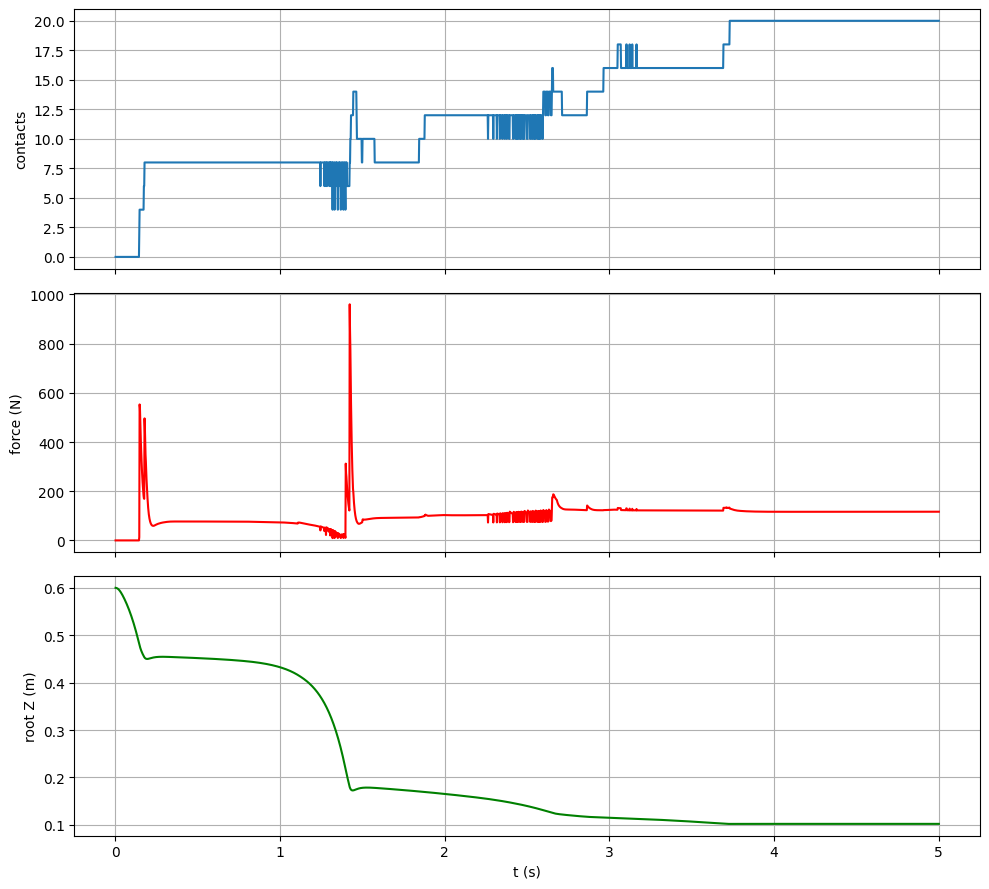

In [4]:
mujoco.mj_resetData(model, data)
data.qpos[2] = 0.6
duration, framerate = 5, 30
frames, t_log, force_log, ncon_log, z_log = [], [], [], [], []

scene_option = mujoco.MjvOption()
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
renderer = mujoco.Renderer(model)

while data.time < duration:
    mujoco.mj_step(model, data)
    total = 0.0
    for i in range(data.ncon):
        f = np.zeros(6); mujoco.mj_contactForce(model, data, i, f)
        total += np.linalg.norm(f[:3])
    t_log.append(data.time); force_log.append(total)
    ncon_log.append(data.ncon); z_log.append(data.qpos[2])
    if data.time * framerate >= len(frames):
        renderer.update_scene(data, camera="follow", scene_option=scene_option)
        frames.append(renderer.render())
renderer.close()
media.show_video(frames, fps=framerate)

fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
a1.plot(t_log, ncon_log); a1.set_ylabel("contacts"); a1.grid(True)
a2.plot(t_log, force_log, "r"); a2.set_ylabel("force (N)"); a2.grid(True)
a3.plot(t_log, z_log, "g"); a3.set_ylabel("root Z (m)"); a3.set_xlabel("t (s)"); a3.grid(True)
plt.tight_layout(); plt.show()

## 4. Reference trajectory replay

In [5]:
# Build the reference qpos from a C3D file (or load an existing trajectory.npz).
files = io.list_c3d_files()
df, point_rate = io.load_c3d(P.C3D_DIR / files[0])
df = kinematics.compute_joint_angles(df)
traj = build.angles_to_trajectory(df, frequency=point_rate)
qpos = traj["qpos"]

framerate = 60
frames = []
renderer = mujoco.Renderer(model)
for i in range(len(qpos)):
    data.qpos[:] = qpos[i]; data.qvel[:] = 0
    mujoco.mj_forward(model, data)
    if traj["time"][i] * framerate >= len(frames):
        renderer.update_scene(data, camera="follow")
        frames.append(renderer.render())
renderer.close()
media.show_video(frames, fps=framerate)

This browser does not support the video tag.


## 5. Total weight & characteristic length

In [6]:
G = 9.81  # m/s^2

# Total mass = sum of all body masses (world body has mass 0)
total_mass = float(model.body_mass.sum())
total_weight = total_mass * G

# Characteristic length: cube root of the model's axis-aligned bounding-box
# volume in the standing pose (a single geometric size scale for the robot).
mujoco.mj_resetData(model, data)
front = np.radians([82, 95, 13])
rear  = np.radians([-78, -120, -42])
for leg, vals in [("fl", front), ("fr", front), ("bl", rear), ("br", rear)]:
    for joint, v in zip(P.JOINT_ORDER, vals):
        data.joint(f"{leg}_{joint}_joint").qpos = v
data.qpos[0:3] = [0, 0, 0.35]
mujoco.mj_forward(model, data)

r = model.geom_rbound[:, None]                 # per-geom bounding-sphere radius
lo = (data.geom_xpos - r).min(axis=0)
hi = (data.geom_xpos + r).max(axis=0)
extent = hi - lo                               # bounding-box size (x, y, z)
char_len = float(np.cbrt(np.prod(extent)))

print(f"Total mass:            {total_mass:.3f} kg")
print(f"Total weight:          {total_weight:.2f} N")
print(f"Bounding box (x,y,z):  {extent[0]:.3f} x {extent[1]:.3f} x {extent[2]:.3f} m")
print(f"Characteristic length: {char_len:.3f} m")

Total mass:            7.834 kg
Total weight:          76.85 N
Bounding box (x,y,z):  0.535 x 0.498 x 0.599 m
Characteristic length: 0.543 m
